In [ ]:
import os
import subprocess
from google.colab import drive

# Step 1: Mount Google Drive
drive.mount('/content/drive')
print(" Google Drive is now connected!")

# Step 2: Tell the user where we expect the ZIP to be
print("\nWe will look for your ZIP inside:")
print("  /content/drive/MyDrive/X_Ray Dataset/")

# Step 3: Check if that folder even exists on Drive
xray_folder = '/content/drive/MyDrive/X_Ray Dataset'

if os.path.exists(xray_folder):
    print(" 'X_Ray Dataset' folder found on Drive!")
else:
    print(" 'X_Ray Dataset' folder NOT found on Drive!")
    print("   Check your Google Drive folder name carefully.")


Mounted at /content/drive
✅ Google Drive is now connected!

We will look for your ZIP inside:
  /content/drive/MyDrive/X_Ray Dataset/
✅ 'X_Ray Dataset' folder found on Drive!


In [ ]:

import os

# The Drive folder we want to search inside
xray_folder = '/content/drive/MyDrive/X_Ray Dataset/Dataset ZIP'

# This variable will store the ZIP path once we find it
drive_zip = None

print("Searching for a .zip file inside 'X_Ray Dataset'...")

# os.walk() goes through every folder and sub-folder one by one
for current_folder, sub_folders, file_names in os.walk(xray_folder):

    # Look at each file in the current folder
    for filename in file_names:

        # Check if this file is a ZIP file
        if filename.endswith('.zip'):

            # Build the full path to the ZIP file
            drive_zip = os.path.join(current_folder, filename)

            # Get the file size so we can confirm it looks right
            size_in_bytes = os.path.getsize(drive_zip)
            size_in_gb    = size_in_bytes / (1024 * 1024 * 1024)

            print(f" Found ZIP file!")
            print(f"   Name : {filename}")
            print(f"   Path : {drive_zip}")
            print(f"   Size : {size_in_gb:.2f} GB")

            # Stop searching — we found it
            break

    # If we already found the ZIP, stop the outer loop too
    if drive_zip is not None:
        break

# Final check — did we find it?
if drive_zip is None:
    print(" No ZIP file found in 'X_Ray Dataset'!")
    print("\nWhat IS inside the folder:")

    # Show everything inside so the user can investigate
    for current_folder, sub_folders, file_names in os.walk(xray_folder):
        for filename in file_names:
            full_path = os.path.join(current_folder, filename)
            size_mb   = os.path.getsize(full_path) / (1024 * 1024)
            print(f"   {full_path}  ({size_mb:.1f} MB)")

    # Stop the notebook here — no point continuing without the ZIP
    raise FileNotFoundError("Cannot continue without the ZIP file!")

print("\n ZIP file located! Ready for Cell 3.")

Searching for a .zip file inside 'X_Ray Dataset'...
✅ Found ZIP file!
   Name : data.zip
   Path : /content/drive/MyDrive/X_Ray Dataset/Dataset ZIP/data.zip
   Size : 38.82 GB

✅ ZIP file located! Ready for Cell 3.


In [ ]:
import os
import subprocess

extract_path = '/content/dataset/'

# These two paths must exist after a successful extraction
raw_check = '/content/dataset/data/raw'
csv_check = '/content/dataset/data/processed/multi/(04)CNN_ready_multiclass.csv'

print("STEP 1: Checking if dataset is already extracted on Colab disk...")

# Check if both the images folder AND the CSV file already exist
raw_ready = os.path.exists(raw_check)
csv_ready = os.path.exists(csv_check)

if raw_ready and csv_ready:
    # Great — nothing to do! Skip the extraction.
    print(" Dataset already on Colab disk — skipping extraction!")
    print(f"   Images folder : {raw_check}")
    print(f"   CSV file      : {csv_check}")

else:
    # Not found — we need to extract the ZIP now
    print("Dataset NOT found on Colab disk.")
    print("STEP 2: Starting extraction from Google Drive...")


    # Create the destination folder if it does not exist yet
    os.makedirs(extract_path, exist_ok=True)

    # Run the unzip command
    result = subprocess.run(
        ['unzip', '-o', '-q', drive_zip, '-d', extract_path],
        capture_output=True,
        text=True
    )

    # Check if unzip worked correctly
    # return code 0 means success, anything else is an error
    if result.returncode != 0:
        print(" Extraction FAILED!")
        print(f"   Error message: {result.stderr}")
        raise RuntimeError("Unzip failed! See the error message above.")
    else:
        print(" Extraction finished!")

# STEP 3: Verify the extracted folder structure
print("\nSTEP 3: Verifying what is now on Colab disk...")
print(f"Looking inside: {extract_path}\n")

if os.path.exists(extract_path):

    # Walk through up to 4 levels deep only
    for current_folder, sub_folders, file_names in os.walk(extract_path):

        # Calculate how deep we are (0 = top level, 1 = one level down, etc.)
        depth = current_folder.replace(extract_path, '').count(os.sep)

        # Stop printing if we are deeper than 4 levels
        if depth > 4:
            continue

        # Build an indent string so the output looks like a tree
        indent       = '    ' * depth
        folder_name  = os.path.basename(current_folder)
        num_files    = len(file_names)

        print(f"{indent} {folder_name}/   ({num_files} files)")

else:
    print(" /content/dataset/ is still empty after extraction!")
    print("   Something went wrong. Please re-run Cell 3.")

STEP 1: Checking if dataset is already extracted on Colab disk...
Dataset NOT found on Colab disk.
STEP 2: Starting extraction from Google Drive...
✅ Extraction finished!

STEP 3: Verifying what is now on Colab disk...
Looking inside: /content/dataset/

📁 /   (0 files)
📁 data/   (0 files)
    📁 processed/   (13 files)
        📁 multi/   (5 files)
    📁 raw/   (9 files)
        📁 images_009/   (0 files)
            📁 images/   (9483 files)
        📁 images_003/   (0 files)
            📁 images/   (8332 files)
        📁 images_012/   (0 files)
            📁 images/   (8572 files)
        📁 images_006/   (0 files)
            📁 images/   (8830 files)
        📁 images_011/   (0 files)
            📁 images/   (9162 files)
        📁 splits/   (0 files)
        📁 images_010/   (0 files)
            📁 images/   (8812 files)
        📁 images_005/   (0 files)
            📁 images/   (8701 files)
        📁 images_002/   (0 files)
            📁 images/   (8173 files)
        📁 images_008/   (0 fil

In [ ]:
# ── Paths (same as your existing notebook) ──────────────────────────────────
CSV_PATH    = '/content/dataset/data/processed/multi/04_CNN_ready_multiclass.csv'
IMAGES_ROOT = '/content/dataset/data/raw'
SAVE_PATH   = '/content/drive/MyDrive/model_output/ResNet34_v1.pt'
CHECKPOINT  = '/content/drive/MyDrive/model_output/ResNet34_v1_checkpoint.pt'

os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

# ── Hyper-parameters (FIXED from previous version) ──────────────────────────
SELECTED_DISEASES = ['Pneumonia', 'Effusion', 'Atelectasis', 'Nodule', 'Cardiomegaly', 'Mass']
NUM_CLASSES  = len(SELECTED_DISEASES)
IMG_SIZE     = 224
BATCH_SIZE   = 64
EPOCHS       = 60
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 20

print(f"Classes: {SELECTED_DISEASES}")
print(f"IMG: {IMG_SIZE}x{IMG_SIZE} | BATCH: {BATCH_SIZE} | EPOCHS: {EPOCHS}")

Classes: ['Pneumonia', 'Effusion', 'Atelectasis', 'Nodule', 'Cardiomegaly', 'Mass']
IMG: 224x224 | BATCH: 64 | EPOCHS: 60


In [ ]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

warnings.filterwarnings('ignore')

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA L4
VRAM: 23.7 GB


In [ ]:
CSV_PATH = '/content/dataset/data/processed/multi/(04)CNN_ready_multiclass.csv'
df = pd.read_csv(CSV_PATH)
df = df[df['Finding Labels'].isin(SELECTED_DISEASES)].copy()
df['label_idx'] = df['Finding Labels'].map({d: i for i, d in enumerate(SELECTED_DISEASES)})
df = df.reset_index(drop=True)

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['Finding Labels'], random_state=42)
val_df,  test_df  = train_test_split(temp_df, test_size=0.50, stratify=temp_df['Finding Labels'], random_state=42)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nClass distribution (Train):\n{train_df['Finding Labels'].value_counts()}")

Train: 9660 | Val: 2070 | Test: 2070

Class distribution (Train):
Finding Labels
Atelectasis     1610
Cardiomegaly    1610
Nodule          1610
Pneumonia       1610
Mass            1610
Effusion        1610
Name: count, dtype: int64


In [ ]:
all_image_paths = glob(os.path.join(IMAGES_ROOT, '**', '*.png'), recursive=True)
image_path_dict = {os.path.basename(p): p for p in all_image_paths}
print(f'Images found: {len(image_path_dict)}')

Images found: 99678


In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.30,
                                     stratify=df['Finding Labels'], random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.50,
                                     stratify=temp_df['Finding Labels'], random_state=42)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train : {len(train_df)}')
print(f'Val   : {len(val_df)}')
print(f'Test  : {len(test_df)}')


Train : 9660
Val   : 2070
Test  : 2070


In [ ]:
df = pd.read_csv(CSV_PATH)
df = df[df['Finding Labels'].isin(SELECTED_DISEASES)].copy()
df['label_idx'] = df['Finding Labels'].map({d: i for i, d in enumerate(SELECTED_DISEASES)})
df = df.reset_index(drop=True)

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['Finding Labels'], random_state=42)
val_df,  test_df  = train_test_split(temp_df, test_size=0.50, stratify=temp_df['Finding Labels'], random_state=42)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nClass distribution (Train):\n{train_df['Finding Labels'].value_counts()}")

Compiling model with torch.compile()...
✅ Model compiled!
Parameters: 21,419,078


In [ ]:
all_image_paths = glob(os.path.join(IMAGES_ROOT, '**', '*.png'), recursive=True)
image_path_dict = {os.path.basename(p): p for p in all_image_paths}
print(f" Images found: {len(image_path_dict)}")

✅ ResNet-32 built!
   Total params     : 21,419,078
   Trainable params : 21,419,078


In [ ]:
def mixup_data(images, labels, alpha=0.3):
    lam        = np.random.beta(alpha, alpha)
    rand_index = torch.randperm(images.size(0), device=images.device)
    mixed      = lam * images + (1 - lam) * images[rand_index]
    return mixed, labels, labels[rand_index], lam

def mixup_criterion(criterion, outputs, la, lb, lam):
    return lam * criterion(outputs, la) + (1 - lam) * criterion(outputs, lb)

print('MixUp ready')

✅ MixUp ready


In [ ]:
all_image_paths = glob(os.path.join(IMAGES_ROOT, '**', '*.png'), recursive=True)
image_path_dict = {os.path.basename(p): p for p in all_image_paths}
print(f" Images found: {len(image_path_dict)}")

✅ Images found: 99678


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_df['label_idx'].values
)
class_weights = torch.tensor(class_weights_array, dtype=torch.float32).to(device)
print(f"Class weights: {class_weights}")

Class weights: tensor([1., 1., 1., 1., 1., 1.], device='cuda:0')


In [ ]:
# ── Train transforms: strong augmentation ────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ── Val/Test transforms: no augmentation ─────────────────────────────────────
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class XRayDataset(Dataset):
    def __init__(self, dataframe, image_path_dict, transform=None):
        self.df = dataframe
        self.path_dict = image_path_dict
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['Image Index']
        label    = int(row['label_idx'])

        img_path = self.path_dict.get(img_name)
        if img_path is None or not os.path.exists(img_path):
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color=128)
        else:
            img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)
        return img, label


train_dataset = XRayDataset(train_df, image_path_dict, transform=train_transforms)
val_dataset   = XRayDataset(val_df,   image_path_dict, transform=val_transforms)
test_dataset  = XRayDataset(test_df,  image_path_dict, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f" DataLoaders ready | Train batches: {len(train_loader)}")

✅ DataLoaders ready | Train batches: 151


In [ ]:
def build_resnet34(num_classes, dropout=0.4):
    # Load pretrained ImageNet weights
    model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

    # ── Freeze early layers (conv1, layer1, layer2) ─────────────────────────
    for name, param in model.named_parameters():
        if any(name.startswith(layer) for layer in ['conv1', 'bn1', 'layer1', 'layer2']):
            param.requires_grad = False

    # ── Replace the final classifier head ───────────────────────────────────
    in_features = model.fc.in_features  # 512 for ResNet-34
    model.fc = nn.Sequential(
        nn.BatchNorm1d(in_features),
        nn.Dropout(p=dropout),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.BatchNorm1d(256),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes),
    )

    # Kaiming init for new head only
    for m in model.fc.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

    return model


model = build_resnet34(NUM_CLASSES).to(device)
model = model.to(memory_format=torch.channels_last)  # faster on GPU

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f" ResNet-34 (pretrained) ready!")
print(f"   Total params    : {total_params:,}")
print(f"   Trainable params: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 242MB/s]


✅ ResNet-34 (pretrained) ready!
   Total params    : 21,419,078
   Trainable params: 20,071,174


In [ ]:
# ── Separate LR for frozen backbone vs new head ──────────────────────────────
backbone_params = [p for name, p in model.named_parameters()
                   if p.requires_grad and not name.startswith('fc')]
head_params     = list(model.fc.parameters())

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': LR * 0.1},   # lower LR for backbone
    {'params': head_params,     'lr': LR},           # higher LR for head
], weight_decay=WEIGHT_DECAY)

scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=1, eta_min=1e-6)

# ── Class-weighted loss (no label smoothing for small dataset) ───────────────
criterion = nn.CrossEntropyLoss(weight=class_weights)

scaler = torch.cuda.amp.GradScaler()

print(f"Optimizer, Scheduler & Loss ready")
print(f"   Backbone LR: {LR * 0.1} | Head LR: {LR}")

✅ Optimizer, Scheduler & Loss ready
   Backbone LR: 0.0001 | Head LR: 0.001


In [ ]:
best_val_acc  = 0.0
best_epoch    = 0
no_improve    = 0
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

# ── Unfreeze all layers after epoch 10 ──────────────────────────────────────
UNFREEZE_EPOCH = 10

print(f"Training ResNet-34 (pretrained) | {EPOCHS} epochs | batch {BATCH_SIZE} | {IMG_SIZE}px")
print("─" * 75)

for epoch in range(EPOCHS):
    t0 = time.time()

    # Unfreeze all layers after warmup
    if epoch == UNFREEZE_EPOCH:
        for param in model.parameters():
            param.requires_grad = True
        print(f"\n Epoch {epoch+1}: All layers unfrozen (full fine-tuning begins)\n")

    # ── TRAIN ────────────────────────────────────────────────────────────────
    model.train()
    run_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True, memory_format=torch.channels_last)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        run_loss += loss.item()
        _, pred   = torch.max(outputs, 1)
        correct  += (pred == labels).sum().item()
        total    += labels.size(0)

    avg_train_loss = run_loss / len(train_loader)
    avg_train_acc  = 100.0 * correct / total

    # ── VALIDATE ─────────────────────────────────────────────────────────────
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True, memory_format=torch.channels_last)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                outputs = model(images)
                loss    = nn.CrossEntropyLoss(weight=class_weights)(outputs, labels)
            v_loss    += loss.item()
            _, pred    = torch.max(outputs, 1)
            v_correct += (pred == labels).sum().item()
            v_total   += labels.size(0)

    avg_val_loss = v_loss / len(val_loader)
    avg_val_acc  = 100.0 * v_correct / v_total

    scheduler.step(epoch)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(avg_train_acc)
    val_accs.append(avg_val_acc)

    elapsed = time.time() - t0
    print(f"Ep {epoch+1:3d}/{EPOCHS} | Train {avg_train_acc:.1f}% Val {avg_val_acc:.1f}% "
          f"| Loss {avg_val_loss:.4f} | {elapsed:.1f}s")

    # ── Save best model ───────────────────────────────────────────────────────
    if avg_val_acc > best_val_acc:
        best_val_acc, best_epoch, no_improve = avg_val_acc, epoch + 1, 0
        torch.save({'epoch': epoch + 1,
                    'model_state_dict': model.state_dict(),
                    'val_acc': best_val_acc}, SAVE_PATH)
        print(f"   Saved! Val Acc: {best_val_acc:.2f}% @ epoch {best_epoch}")
    else:
        no_improve += 1
        print(f"  ⏸ No improve {no_improve}/{PATIENCE}")

    # ── Checkpoint every 5 epochs ────────────────────────────────────────────
    if (epoch + 1) % 5 == 0:
        torch.save({'epoch': epoch + 1,
                    'model_state_dict': model.state_dict(),
                    'train_losses': train_losses, 'val_losses': val_losses,
                    'train_accs': train_accs,     'val_accs': val_accs}, CHECKPOINT)

    if no_improve >= PATIENCE:
        print(f"\n Early stop at epoch {epoch+1} | Best: {best_val_acc:.2f}% @ ep {best_epoch}")
        break

print(f"\n Done! Best Val Acc: {best_val_acc:.2f}% at epoch {best_epoch}")

Training ResNet-34 (pretrained) | 50 epochs | batch 64 | 224px
───────────────────────────────────────────────────────────────────────────
Ep   1/50 | Train 23.3% Val 30.0% | Loss 3.2591 | 99.0s
  ✅ Saved! Val Acc: 29.95% @ epoch 1
Ep   2/50 | Train 26.9% Val 35.0% | Loss 2.1116 | 73.7s
  ✅ Saved! Val Acc: 34.98% @ epoch 2
Ep   3/50 | Train 31.0% Val 39.1% | Loss 1.9870 | 73.1s
  ✅ Saved! Val Acc: 39.13% @ epoch 3
Ep   4/50 | Train 34.0% Val 41.0% | Loss 1.4944 | 73.3s
  ✅ Saved! Val Acc: 41.01% @ epoch 4
Ep   5/50 | Train 36.4% Val 43.0% | Loss 2.3909 | 73.4s
  ✅ Saved! Val Acc: 43.04% @ epoch 5
Ep   6/50 | Train 39.3% Val 42.2% | Loss 2.3726 | 73.7s
  ⏸ No improve 1/20
Ep   7/50 | Train 43.1% Val 41.1% | Loss 3.3716 | 73.4s
  ⏸ No improve 2/20
Ep   8/50 | Train 43.2% Val 43.8% | Loss 1.8980 | 73.6s
  ✅ Saved! Val Acc: 43.77% @ epoch 8
Ep   9/50 | Train 45.6% Val 45.1% | Loss 2.9793 | 73.0s
  ✅ Saved! Val Acc: 45.12% @ epoch 9
Ep  10/50 | Train 46.7% Val 46.5% | Loss 3.0365 | 73.3s
  

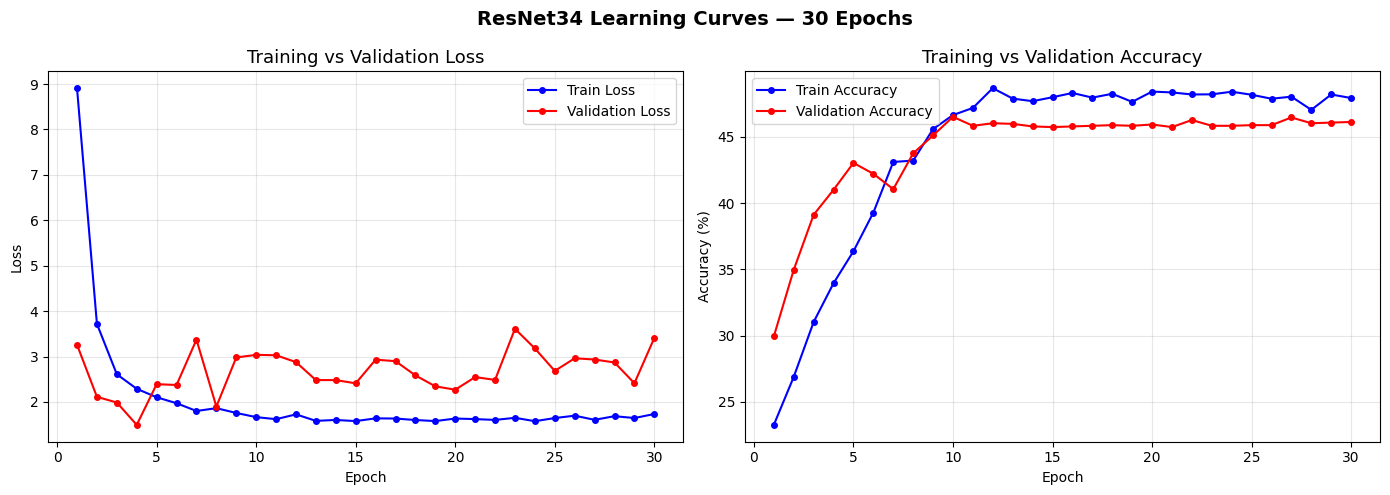

✅ Learning curves saved: learning_curves.png


In [ ]:
#Plot Training & Validation Loss and Accuracy curves
epochs_range = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss Curve ---
ax1.plot(epochs_range, train_losses, 'b-o', label='Train Loss',      markersize=4)
ax1.plot(epochs_range, val_losses,   'r-o', label='Validation Loss', markersize=4)
ax1.set_title('Training vs Validation Loss', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Accuracy Curve ---
ax2.plot(epochs_range, train_accs, 'b-o', label='Train Accuracy',      markersize=4)
ax2.plot(epochs_range, val_accs,   'r-o', label='Validation Accuracy', markersize=4)
ax2.set_title('Training vs Validation Accuracy', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f'ResNet34 Learning Curves — {len(train_losses)} Epochs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/learning_curves.png', dpi=150)
plt.show()
print(" Learning curves saved: learning_curves.png")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Pneumonia       0.67      0.43      0.52       345
    Effusion       0.37      0.42      0.39       345
 Atelectasis       0.38      0.43      0.40       345
      Nodule       0.38      0.47      0.42       345
Cardiomegaly       0.62      0.75      0.68       345
        Mass       0.42      0.27      0.33       345

    accuracy                           0.46      2070
   macro avg       0.47      0.46      0.46      2070
weighted avg       0.47      0.46      0.46      2070



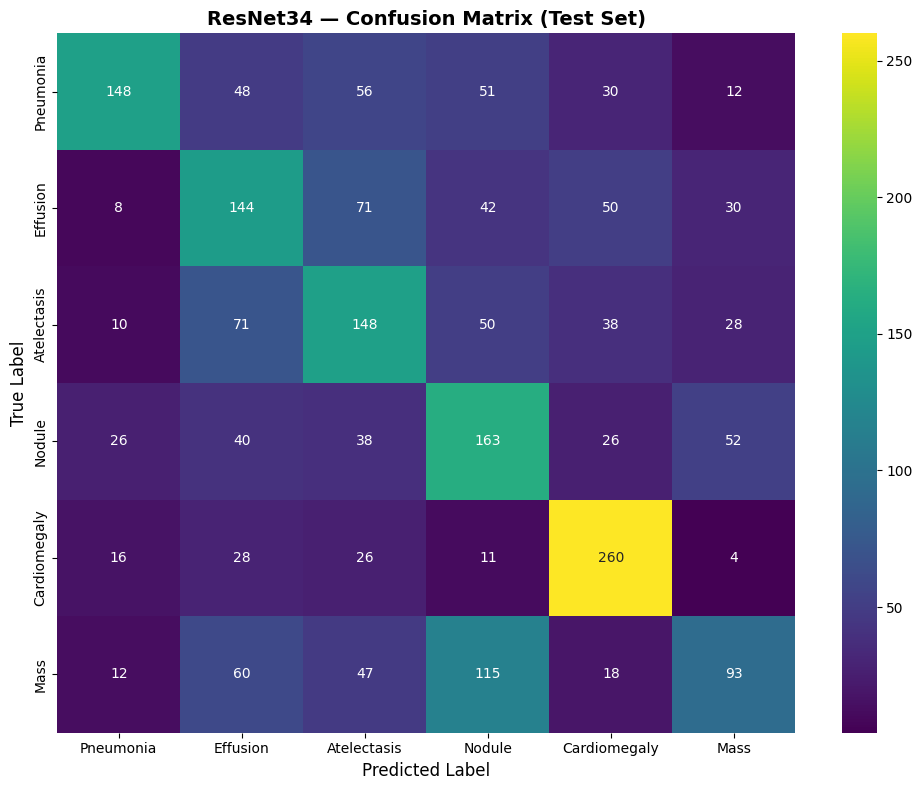

✅ Confusion matrix saved!


In [ ]:
# ── CELL: Evaluation on Test Set ──
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from torch.cuda.amp import autocast # Import autocast

# Load best saved model weights
loaded_checkpoint = torch.load(SAVE_PATH, map_location=device)
model.load_state_dict(loaded_checkpoint['model_state_dict'])
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        with autocast():
            outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())

# Classification report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=SELECTED_DISEASES))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=SELECTED_DISEASES, yticklabels=SELECTED_DISEASES, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('ResNet34 — Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()
print(" Confusion matrix saved!")

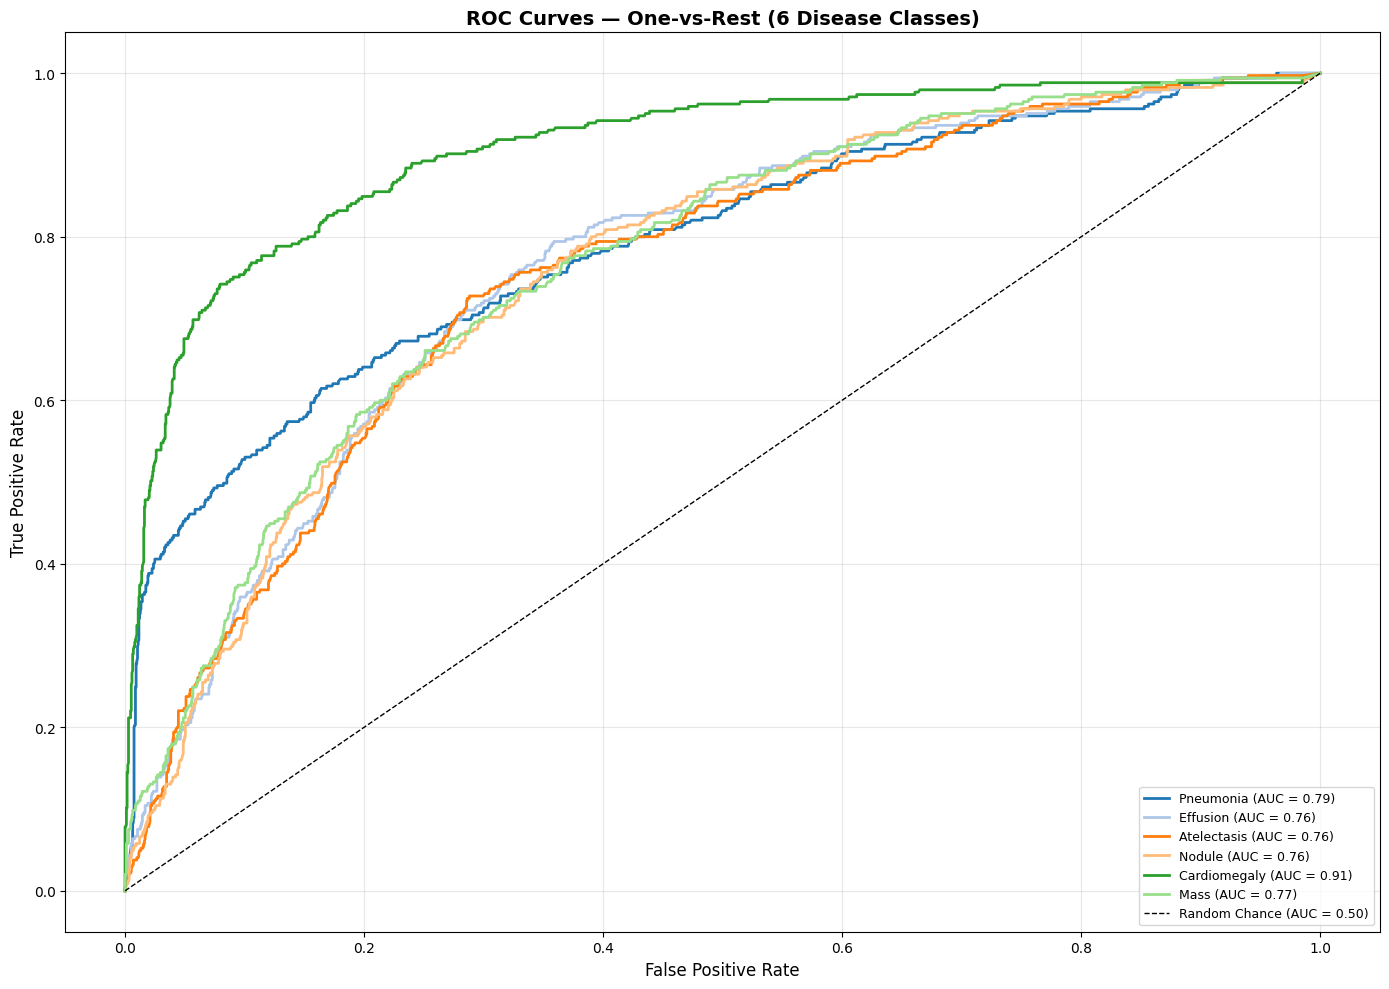

✅ ROC curves saved: roc_curves.png

💡 AUC closer to 1.0 = model is better at detecting that disease.


In [ ]:
from sklearn.preprocessing import label_binarize
import numpy as np

# Convert to numpy arrays if they aren't already (important for slicing)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Binarize labels for One-vs-Rest ROC
y_true_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(14, 10))
colors_roc = plt.cm.tab20.colors

for i, class_name in enumerate(SELECTED_DISEASES):
    # Get ROC curve for this class vs all others
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc      = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=colors_roc[i], lw=2,
             label=f'{class_name} (AUC = {roc_auc:.2f})')

# Plot the random-chance diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance (AUC = 0.50)')

plt.title(f'ROC Curves — One-vs-Rest ({len(SELECTED_DISEASES)} Disease Classes)', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate',  fontsize=12)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_curves.png', dpi=150)
plt.show()
print(" ROC curves saved: roc_curves.png")
print("\n AUC closer to 1.0 = model is better at detecting that disease.")

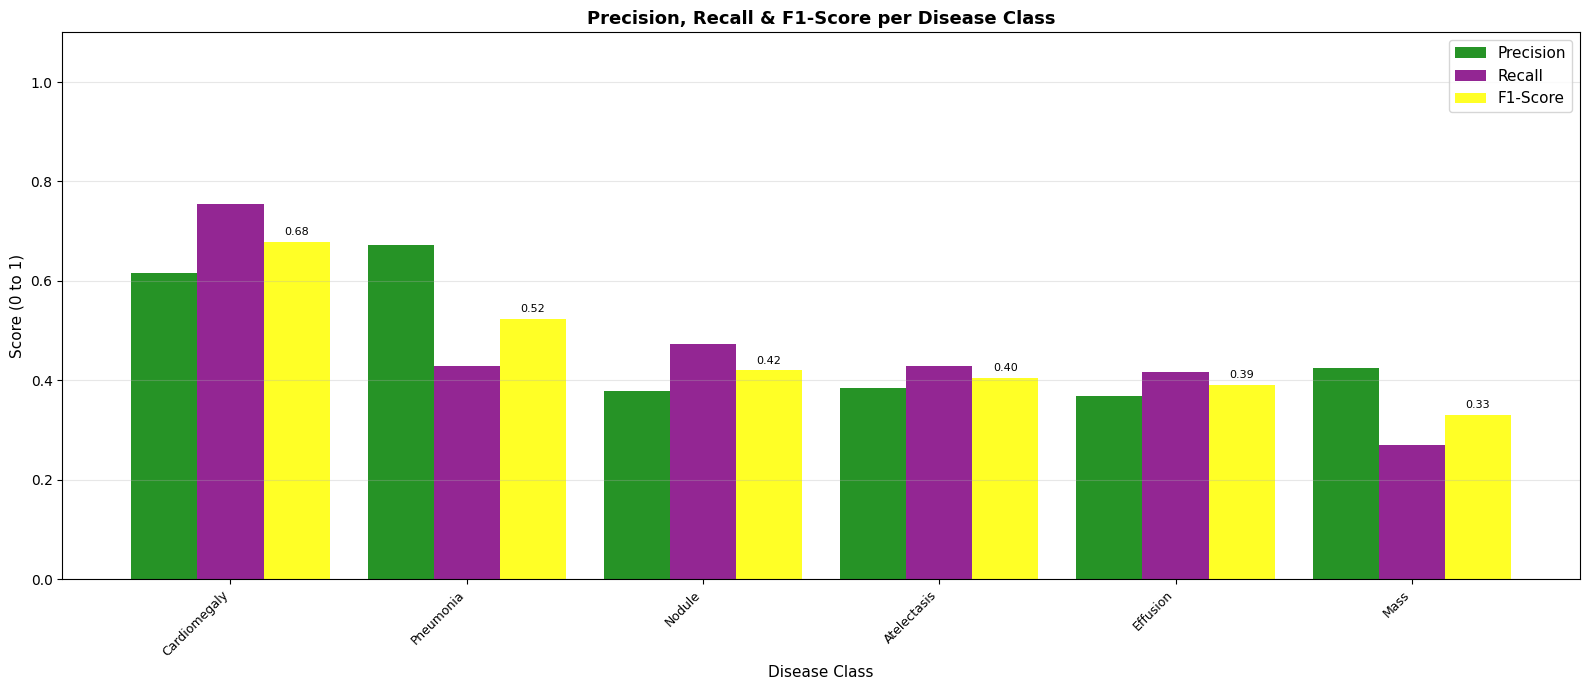

✅ F1-score chart saved: f1_scores.png


In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Calculate F1, Precision, and Recall for each class
f1_scores  = f1_score(all_labels, all_preds, average=None)
precisions = precision_score(all_labels, all_preds, average=None, zero_division=0)
recalls    = recall_score(all_labels, all_preds, average=None, zero_division=0)

# Sort by F1 score for easier reading
sorted_idx  = np.argsort(f1_scores)[::-1]
sorted_cls  = [SELECTED_DISEASES[i] for i in sorted_idx]
sorted_f1   = f1_scores[sorted_idx]
sorted_prec = precisions[sorted_idx]
sorted_rec  = recalls[sorted_idx]

x     = np.arange(len(SELECTED_DISEASES))
width = 0.28

fig, ax = plt.subplots(figsize=(16, 7))
bars1 = ax.bar(x - width, sorted_prec, width, label='Precision', color='green',  alpha=0.85)
bars2 = ax.bar(x,         sorted_rec,  width, label='Recall',    color='purple', alpha=0.85)
bars3 = ax.bar(x + width, sorted_f1,   width, label='F1-Score',  color='yellow',   alpha=0.85)

ax.set_title('Precision, Recall & F1-Score per Disease Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Disease Class', fontsize=11)
ax.set_ylabel('Score (0 to 1)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(sorted_cls, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

# Add value labels on top of F1 bars
for bar in bars3:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
            f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/content/f1_scores.png', dpi=150)
plt.show()
print(" F1-score chart saved: f1_scores.png")

Generating Grad-CAM heatmaps...


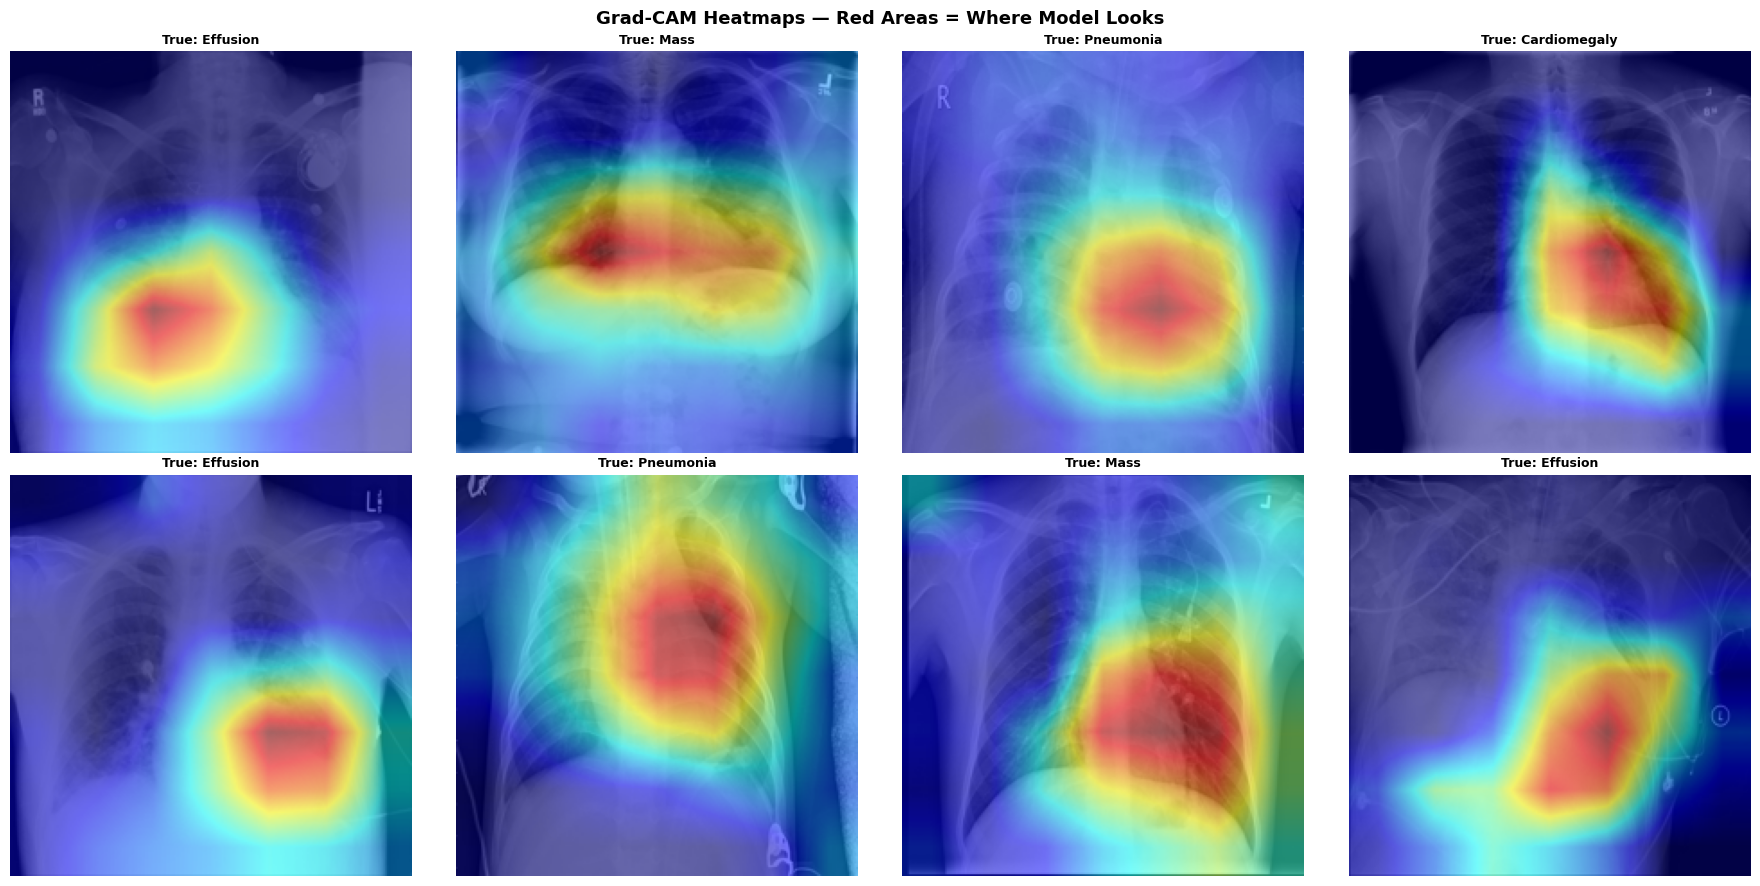

✅ Grad-CAM heatmaps saved: gradcam_heatmaps.png

Red/yellow = high attention. Blue = ignored.
 Ideally, hotspots should be on the lungs — not the background or text!


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Define the transformation for validation/test images
valtest_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet standards
])

# We target the last convolutional layer in EfficientNet
target_layer = [model.layer4]

# Set up Grad-CAM
cam = GradCAM(model=model, target_layers=target_layer)

# Pick 8 test images to visualize (2 from first 4 classes)
print("Generating Grad-CAM heatmaps...")

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

count = 0
for idx in range(len(test_df)):
    if count >= 8:
        break

    row      = test_df.iloc[idx]
    img_name = row['Image Index']
    label    = int(row['label_idx']) # Changed 'label' to 'label_idx'
    img_path = image_path_dict.get(img_name)

    if img_path is None or not os.path.exists(img_path):
        continue

    # Load original image for display
    # Resize to IMG_SIZE to match the heatmap dimensions
    orig_img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    orig_np  = np.array(orig_img) / 255.0  # Normalize to 0-1 for overlay

    # Prepare tensor for model
    input_tensor = valtest_transform(orig_img).unsqueeze(0).to(device)

    # Generate Grad-CAM for the true class
    targets    = [ClassifierOutputTarget(label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]  # Remove batch dimension

    # Overlay heatmap on original image
    visualization = show_cam_on_image(orig_np.astype(np.float32),
                                      grayscale_cam, use_rgb=True)

    axes[count].imshow(visualization)
    axes[count].set_title(f'True: {SELECTED_DISEASES[label]}', fontsize=9, fontweight='bold')
    axes[count].axis('off')
    count += 1

plt.suptitle('Grad-CAM Heatmaps — Red Areas = Where Model Looks',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/gradcam_heatmaps.png', dpi=150)
plt.show()
print("Grad-CAM heatmaps saved: gradcam_heatmaps.png")
print("\nRed/yellow = high attention. Blue = ignored.")
print(" Ideally, hotspots should be on the lungs — not the background or text!")

In [ ]:
import shutil
from sklearn.metrics import accuracy_score

# Create a folder on Drive to store all results
results_drive = '/content/drive/MyDrive/X_Ray_Dataset/training_results/'
os.makedirs(results_drive, exist_ok=True)

# List of all saved plots
plots = [
    '/content/distribution_before.png',
    '/content/distribution_after.png',
    '/content/sample_grid.png',
    '/content/learning_curves.png',
    '/content/confusion_matrix.png',
    '/content/roc_curves.png',
    '/content/f1_scores.png',
    '/content/gradcam_heatmaps.png',
]

for plot_path in plots:
    if os.path.exists(plot_path):
        shutil.copy(plot_path, results_drive)
        print(f" Copied: {os.path.basename(plot_path)}")
    else:
        print(f"Not found: {plot_path}")

print(f"\nAll results saved to Drive: {results_drive}")
print(f" Model saved at: {SAVE_PATH}")

# Retrieve missing variables for summary
current_batch_size = train_loader.batch_size
# best_val_loss was not explicitly tracked, but we can get the loss from the best_epoch
current_best_val_loss = val_losses[best_epoch - 1]

# Calculate test accuracy from previously computed all_labels and all_preds
test_acc = accuracy_score(all_labels, all_preds) * 100

print("\n========== FINAL TRAINING SUMMARY ==========")
print(f"Dataset     : NIH ChestX-ray14 (filtered)")
print(f"Classes     : {NUM_CLASSES} disease classes")
print(f"Train size  : {len(train_df)} images")
print(f"Val size    : {len(val_df)} images")
print(f"Test size   : {len(test_df)} images")
print(f"Epochs      : {EPOCHS}")
print(f"Batch size  : {current_batch_size}")
print(f"Best Val Loss: {current_best_val_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print("============================================")

Not found: /content/distribution_before.png
Not found: /content/distribution_after.png
Not found: /content/sample_grid.png
✅ Copied: learning_curves.png
✅ Copied: confusion_matrix.png
✅ Copied: roc_curves.png
✅ Copied: f1_scores.png
✅ Copied: gradcam_heatmaps.png

All results saved to Drive: /content/drive/MyDrive/X_Ray_Dataset/training_results/
 Model saved at: /content/drive/MyDrive/model_output/ResNet34_v1.pt

========== FINAL TRAINING SUMMARY ==========
Dataset     : NIH ChestX-ray14 (filtered)
Classes     : 6 disease classes
Train size  : 9660 images
Val size    : 2070 images
Test size   : 2070 images
Epochs      : 50
Batch size  : 64
Best Val Loss: 3.0365
Test Accuracy: 46.18%


In [ ]:
from google.colab import files
files.download('/content/untitled20.ipyng')

SyntaxError: unterminated string literal (detected at line 2) (1038370524.py, line 2)